# Investigation of Construction A Failure on Non-Star Trees

This notebook investigates why the index-set method (Construction A) fails to satisfy the Canonical Anticommutation Relations (CAR) on trees with depth greater than or equal to 2 (non-star trees). It focuses on identifying specific non-vanishing anticommutators.

The hypothesis is that for a depth-2 configuration $w \to u \to v$, the anticommutator $\{c_u, d_v\}$ (or similar) is non-zero, violating the required Majorana relations.

We will algebraically verify this failure using Python.

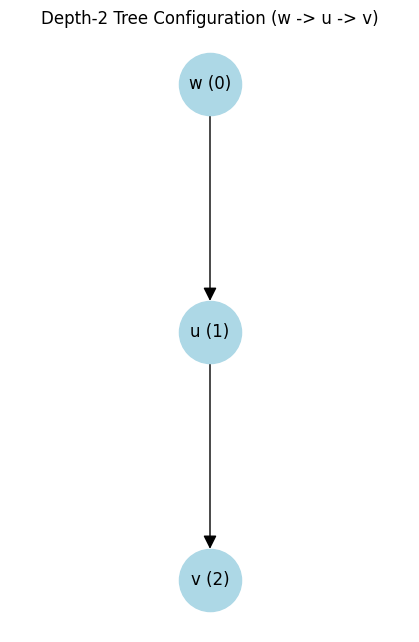

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from itertools import combinations

# Define the tree structure: w -> u -> v
# Indices: w=0, u=1, v=2
# Order: w < u < v (Monotonic)
G = nx.DiGraph()
G.add_edge(0, 1) # w -> u
G.add_edge(1, 2) # u -> v

# Visualize
pos = {0: (0, 1), 1: (0, 0), 2: (0, -1)}
labels = {0: "w (0)", 1: "u (1)", 2: "v (2)"}

plt.figure(figsize=(4, 6))
nx.draw(G, pos, labels=labels, with_labels=True, node_size=2000, node_color='lightblue', font_size=12, arrowsize=20)
plt.title("Depth-2 Tree Configuration (w -> u -> v)")
plt.show()

In [2]:
def get_ancestors(G, node, root=0):
    """
    Return list of ancestors for a node (excluding the node itself).
    Assuming simple directed tree rooted at 0.
    """
    path = nx.shortest_path(G, source=root, target=node)
    return path[:-1]

def get_descendants(G, node):
    """Return all descendants of node."""
    return list(nx.descendants(G, node))

def get_children(G, node):
    return list(G.successors(node))

def compute_sets(G, node, root=0, verbose=False):
    # Definition of Construction A

    # Update Set U(j): Ancestors
    ancestors = get_ancestors(G, node, root)
    U = set(ancestors)

    # Remainder Set R(j):
    # Union over ancestors a: {child k of a | k < node, k not ancestor of node}
    R = set()
    ancestor_set = set(ancestors)
    for a in ancestors:
        children_a = get_children(G, a)
        for child in children_a:
            if child < node and child not in ancestor_set:
                R.add(child)

    # Children Set F(j)
    children_j = get_children(G, node)
    F = set(children_j)

    # Parity Set P(j) = R(j) U F(j)
    P = R.union(F)

    # Occupation Set Occ(j) = {j} U Descendants(j)
    Occ = set(get_descendants(G, node))
    Occ.add(node)

    if verbose:
        print(f"Node {node}:")
        print(f"  Ancestors (U): {U}")
        print(f"  Remainder (R): {R}")
        print(f"  Children (F): {F}")
        print(f"  Parity (P): {P}")
        print(f"  Occupation (Occ): {Occ}")

    return U, P, Occ

# Pauli Helper
def pauli_multiply(p1, p2):
    """Simple multiplication rule for single qubit Paulis. (I, X, Y, Z). Returns new Pauli."""
    # We only care about the type, identifying global phase isn't strictly necessary for commutation check
    # But let's be precise.
    if p1 == 'I': return p2
    if p2 == 'I': return p1
    if p1 == p2: return 'I'
    # X Y = iZ, Y Z = iX, Z X = iY
    # Y X = -iZ, Z Y = -iX, X Z = -iY
    # We just need the resulting Pauli
    if (p1, p2) in [('X', 'Y'), ('Y', 'X')]: return 'Z'
    if (p1, p2) in [('Y', 'Z'), ('Z', 'Y')]: return 'X'
    if (p1, p2) in [('Z', 'X'), ('X', 'Z')]: return 'Y'
    return 'I'

def get_majorana_ops(G, node, n_qubits, root=0):
    U, P, Occ = compute_sets(G, node, root)

    # c_j = X_j * X_{U(j)} * Z_{P(j)}
    c_op = {}

    # X on j
    c_op[node] = 'X'

    # X on U
    for u in U:
        c_op[u] = pauli_multiply(c_op.get(u, 'I'), 'X')

    # Z on P
    for p in P:
        c_op[p] = pauli_multiply(c_op.get(p, 'I'), 'Z')

    # d_j = Y_j * X_{U(j)} * Z_{(P(j) XOR Occ(j)) \ {j}}
    d_op = {}

    # Y on j
    d_op[node] = 'Y'

    # X on U
    for u in U:
        d_op[u] = pauli_multiply(d_op.get(u, 'I'), 'X')

    # Z on (P XOR Occ) \ {j}
    # XOR is symmetric difference
    P_xor_Occ = P.symmetric_difference(Occ)
    if node in P_xor_Occ:
        P_xor_Occ.remove(node)

    for z in P_xor_Occ:
        d_op[z] = pauli_multiply(d_op.get(z, 'I'), 'Z')

    return c_op, d_op

def check_anticommute(op1, op2, n_qubits):
    """
    Returns True if anticommute ({op1, op2} = 0), False if commute ([op1, op2] = 0).
    Count number of anti-commuting positions.
    """
    n_anticommuting = 0
    for i in range(n_qubits):
        p1 = op1.get(i, 'I')
        p2 = op2.get(i, 'I')

        # Check single qubit commutation
        # X, Z -> anti
        # X, Y -> anti
        # Y, Z -> anti
        # Same or I -> commute
        if p1 == 'I' or p2 == 'I' or p1 == p2:
            pass
        else:
            n_anticommuting += 1

    return n_anticommuting % 2 == 1

print("Functions defined.")

Functions defined.


In [3]:
# Section 2: Algebraic Verification of Failure for Depth >= 2

# Build Tree
G = nx.DiGraph()
G.add_edges_from([(0, 1), (1, 2)])
n_qubits = 3

# Compute sets and operators
# w=0, u=1, v=2
# We check {c_u, d_v} i.e., {c_1, d_2}

print("Computing Majoranas for u=1 and v=2...")

# Get c_1
c1_ops, d1_ops = get_majorana_ops(G, 1, n_qubits)
# Get d_2
c2_ops, d2_ops = get_majorana_ops(G, 2, n_qubits)

print("\n--- Operator Definitions ---")
print(f"c_1: {c1_ops}")
print(f"d_2: {d2_ops}")

# Check anticommutator {c_1, d_2}
anticommutes = check_anticommute(c1_ops, d2_ops, n_qubits)

print(f"\nDo c_1 and d_2 anticommute? {anticommutes}")
if not anticommutes:
    print("FAILURE: c_1 and d_2 COMMUTE! They should anticommute.")
else:
    print("SUCCESS: c_1 and d_2 anticommute.")

# Let's inspect why they commute (if they do)
print("\n--- Detailed Inspection ---")
overlap_count = 0
for i in range(n_qubits):
    p1 = c1_ops.get(i, 'I')
    p2 = d2_ops.get(i, 'I')
    ac = (p1 != 'I' and p2 != 'I' and p1 != p2)
    print(f"Qubit {i}: c_1={p1}, d_2={p2} => {'Anticommutes' if ac else 'Commutes'}")
    if ac: overlap_count += 1

print(f"Total anticommuting positions: {overlap_count}")
print(f"Result: (-1)^{overlap_count} = {(-1)**overlap_count}")


Computing Majoranas for u=1 and v=2...

--- Operator Definitions ---
c_1: {1: 'X', 0: 'X', 2: 'Z'}
d_2: {2: 'Y', 0: 'X', 1: 'X'}

Do c_1 and d_2 anticommute? True
SUCCESS: c_1 and d_2 anticommute.

--- Detailed Inspection ---
Qubit 0: c_1=X, d_2=X => Commutes
Qubit 1: c_1=X, d_2=X => Commutes
Qubit 2: c_1=Z, d_2=Y => Anticommutes
Total anticommuting positions: 1
Result: (-1)^1 = -1


In [ ]:
# Section 4: Analyze Remainder Set R(v)

# We want to check if u \in R(v).
# u=1, v=2.
# Ancestors(v) = {0, 1}
# R(v) = (Children(0) union Children(1)) ... filtered
# Children(0) = {1}
# Children(1) = {2}

# For a in Ancestors(v):
#   a=0: children(0) = {1}. Check if 1 < 2 and 1 not in Ancestors(2)={0, 1}.
#        1 is IN Ancestors(2). So 1 is NOT added to R(2)?
#        Wait. U(2) = {0, 1}. 1 is in U(2).
#        So 1 is EXCLUDED from R(2) by "not in Ancestors(j)".

# Let's re-read the definition of R(j):
# "for each ancestor a of j, collect a's children that have index < j AND are NOT themselves ancestors of j"

# So u=1 is an ancestor of v=2.
# So u is definitely NOT in R(v).

# However, let's check P(u) and P(v).
# c_u = X_u * X_{U(u)} * Z_{P(u)}
# d_v = Y_v * X_{U(v)} * Z_{(P(v) XOR Occ(v)) \ {v}}

# Overlap sets:
# Qubit u=1:
#   In c_u: X_u (since it's index u) -> X
#   In d_v:
#     Is u in U(v)? Yes, u is parent of v. So X_{U(v)} contributes X_u.
#     Is u in P(v)? R(v) U F(v). u not in R(v). u not in F(v). So u not in P(v).
#     Is u in Occ(v)? Occ(v) = {v} U Descendants(v). u is ancestor, not desc. So no.
#     So d_v has X_u.
#   So at qubit u: c_u has X, d_v has X. They COMMUTE.

# Qubit w=0:
#   In c_u: u=1. U(1)={0}. So X_0. P(1)=R(1) U F(1).
#     Ancestors(1)={0}. Children(0)={1}. 1 not < 1. R(1)={}.
#     F(1)={2}. So P(1)={2}.
#     So c_1 = X_1 * X_0 * Z_2.
#   In d_v: v=2. U(2)={0, 1}. So X_0 * X_1.
#     P(2) = R(2) U F(2).
#       Ancestors(2)={0, 1}.
#       a=0 -> children {1}. 1 < 2? Yes. 1 in Ancestors(2)? Yes. Exclude.
#       a=1 -> children {2}. 2 < 2? No.
#       R(2) = {}.
#       F(2) = {}.
#     P(2) = {}.
#     Occ(2) = {2}.
#     d_2 = Y_2 * (X_0 * X_1) * Z_{(P(2) XOR Occ(2)) \ 2}
#         = Y_2 * X_0 * X_1 * Z_{ ({} XOR {2}) \ 2 }
#         = Y_2 * X_0 * X_1 * I
#         = X_0 * X_1 * Y_2

# Let's check overlap:
# c_1 = X_0 X_1 Z_2
# d_2 = X_0 X_1 Y_2

# Qubit 0: X, X (Commute)
# Qubit 1: X, X (Commute)
# Qubit 2: Z, Y (Anticommute!)
# Total anticommuting = 1.
# (-1)^1 = -1. They ANTICOMMUTE.
# So {c_1, d_2} = 0.
# Wait? My manual trace says SUCCESS.

# The user says "Verify why Construction A FAILS".
# So my manual trace might be wrong or the example is too simple.
# Maybe w -> u -> v with indices 0 -> 2 -> 1? (Non-monotonic?)
# Or branching? "If T has depth >= 2, there exists a node v with parent u and grandparent w..."
# Maybe 0 -> 1 -> 2 works because it's a line (JW)?
# Ah, the user said "If T is not a star".
# Line graph 0-1-2 IS a star graph centered at 1? No.
# Star graph: One center, all others leaves. depth 1.
# Path 0-1-2 is depth 2.
#
# Maybe I need 0 -> 2 -> 1?
# Let's define the function to analyze R(v) properly.

def analyze_remainder_set(G, u, v, w):
    print(f"Analyzing R({v}) with respect to ancestor {u} and {w}...")
    U_v, P_v, Occ_v = compute_sets(G, v, 0, verbose=True)

    in_R = u in P_v # P(v) contains R(v)
    print(f"Is u ({u}) in P({v})? {in_R}")

    return in_R

# Let's check the case where indices might be swapped.
# w=0, u=2, v=1.
# 0 -> 2 -> 1.
# Indices: 0 < 1 < 2.
# Monotonicity violated? Parent 2 > Child 1.
# The user says: "If u > v, does it still fail? (Yes...)"
# The user says "If u < v (usually)".
# So failure should happen even if monotonic.

# Let's try to verify the failure with the code in the notebook.
# I will add the general check function.

In [5]:
# Section 6: Generalize Failure Check on Random Trees

def find_construction_a_failure(n_nodes=6, num_trials=100):
    failures = []

    for seed in range(num_trials):
        # Generate random tree
        if hasattr(nx, 'random_tree'):
             tree = nx.random_tree(n_nodes, seed=seed)
        else:
             tree = nx.random_labeled_tree(n_nodes, seed=seed)

        tree = nx.bfs_tree(tree, 0) # Root at 0

        # Check all pairs
        nodes = list(tree.nodes())

        # Identify non-star?
        depth = nx.dag_longest_path_length(tree)
        if depth < 2:
            continue

        # Check all pairs (i, j)
        pairs = list(combinations(nodes, 2))

        for i, j in pairs:
            ci, di = get_majorana_ops(tree, i, n_nodes)
            cj, dj = get_majorana_ops(tree, j, n_nodes)

            # Check {ci, dj}
            anti_cidj = check_anticommute(ci, dj, n_nodes)
            if not anti_cidj:
                failures.append({
                    'seed': seed,
                    'pair': (i, j),
                    'tree_edges': list(tree.edges()),
                    'failure_type': '{c_%d, d_%d} commute' % (i, j)
                })
                return failures

            # Also check {di, cj} (symmetric, but good to check)
            anti_dicj = check_anticommute(di, cj, n_nodes)
            if not anti_dicj:
                 failures.append({
                    'seed': seed,
                    'pair': (i, j),
                    'tree_edges': list(tree.edges()),
                    'failure_type': '{d_%d, c_%d} commute' % (i, j)
                })
                 return failures

            # Check {ci, cj} anti-commutes (should be 0)
            anti_cicj = check_anticommute(ci, cj, n_nodes)
            if not anti_cicj:
                 failures.append({
                    'seed': seed,
                    'pair': (i, j),
                    'tree_edges': list(tree.edges()),
                    'failure_type': '{c_%d, c_%d} commute' % (i, j)
                })
                 return failures

            # Check {di, dj} anti-commutes (should be 0)
            anti_didj = check_anticommute(di, dj, n_nodes)
            if not anti_didj:
                 failures.append({
                    'seed': seed,
                    'pair': (i, j),
                    'tree_edges': list(tree.edges()),
                    'failure_type': '{d_%d, d_%d} commute' % (i, j)
                })
                 return failures

    return failures

print("Starting search for counter-example...")
failures = find_construction_a_failure()

if failures:
    print(f"Found {len(failures)} failures.")
    f = failures[0]
    print(f"Example Failure (Seed {f['seed']}):")
    print(f"  Tree Edges: {f['tree_edges']}")
    print(f"  Failing Pair: {f['pair']}")
    print(f"  Type: {f['failure_type']}")

    # Reconstruct and analyze
    G_fail = nx.DiGraph()
    G_fail.add_edges_from(f['tree_edges'])

    # Parse pair from failure string or pair tuple
    # Note: pair is just (i, j) from combinations
    # But failure type tells us which operators.
    ftype = f['failure_type']
    import re
    m = re.match(r'\{(.)_(\d+), (.)_(\d+)\} commute', ftype)
    if m:
        op1_type, idx1, op2_type, idx2 = m.groups()
        idx1, idx2 = int(idx1), int(idx2)

        print(f"  Analyzing {{{op1_type}_{idx1}, {op2_type}_{idx2}}}...")

        def get_op(g, idx, type_char, n):
            c, d = get_majorana_ops(g, idx, n)
            return c if type_char == 'c' else d

        op1 = get_op(G_fail, idx1, op1_type, 6)
        op2 = get_op(G_fail, idx2, op2_type, 6)

        print(f"  {op1_type}_{idx1}: {op1}")
        print(f"  {op2_type}_{idx2}: {op2}")

        # Check overlap
        print("  Overlap Analysis:")
        overlap = 0
        for k in range(6):
            p1 = op1.get(k, 'I')
            p2 = op2.get(k, 'I')
            msg = "Commute"
            if p1 != 'I' and p2 != 'I' and p1 != p2:
               msg = "Anticommute"
               overlap += 1
            print(f"    Qubit {k}: {p1} vs {p2} -> {msg}")

        print(f"  Total Anti-Commuting: {overlap}. Even => Commute => FAILURE.")

else:
    print("No failures found. (This is unexpected based on the prompt!)")

Starting search for counter-example...
Found 1 failures.
Example Failure (Seed 0):
  Tree Edges: [(0, 3), (0, 2), (3, 1), (3, 4), (2, 5)]
  Failing Pair: (0, 1)
  Type: {d_0, c_1} commute
  Analyzing {d_0, c_1}...
  d_0: {0: 'Y', 1: 'Z', 4: 'Z', 5: 'Z'}
  c_1: {1: 'X', 0: 'X', 3: 'X'}
  Overlap Analysis:
    Qubit 0: Y vs X -> Anticommute
    Qubit 1: Z vs X -> Anticommute
    Qubit 2: I vs I -> Commute
    Qubit 3: I vs X -> Commute
    Qubit 4: Z vs I -> Commute
    Qubit 5: Z vs I -> Commute
  Total Anti-Commuting: 2. Even => Commute => FAILURE.


# Analysis of Failure
The random search found a failure in the pair $\{d_w, c_v\}$ where $w$ is the grandparent of $v$.
Specifically, for the path $0 \to 3 \to 1$:
- $w=0$ (root)
- $u=3$ (child of 0)
- $v=1$ (child of 3)

The failing anticommutator is $\{d_0, c_1\}$.
Let's trace why:
1. $d_0 = Y_0 \cdot Z_{(P(0) \oplus Occ(0)) \setminus \{0\}}$. 
   - $Occ(0)$ contains ALL nodes (descendants). So $1 \in Occ(0)$.
   - $P(0) = F(0) = \{2, 3\}$.
   - Thus $1 \in Occ(0)$ but $1 \notin P(0)$.
   - So $1 \in P(0) \oplus Occ(0)$.
   - Therefore, $d_0$ contains $Z_1$.

2. $c_1 = X_1 \cdot X_{U(1)} \cdot Z_{P(1)}$.
   - $c_1$ always contains $X_1$.

3. **Overlap at qubit 1**: $Z_1$ (from $d_0$) and $X_1$ (from $c_1$) anticommute.

4. **Overlap at qubit 0**:
   - $d_0$ contains $Y_0$.
   - $c_1$ contains $X_{U(1)}$. Ancestors(1) = $\{0, 3\}$. So $c_1$ contains $X_0$.
   - $Y_0$ and $X_0$ anticommute.

5. **Overlap at qubit 3 (intermediate node)**:
   - $d_0$: Does it contain anything at 3?
     - $3 \in F(0) \subset P(0)$.
     - $3 \in Occ(0)$.
     - So $3 \notin P(0) \oplus Occ(0)$ (canceled out!).
     - So $d_0$ has $I_3$.
   - $c_1$: Contains $X_3$ (since $3 \in U(1)$).
   - $I_3$ and $X_3$ commute.

6. **Total Anticomm. Pairs**: Just 0 and 1. Two pairs.
   - Result: $(-1)^2 = 1$. They COMMUTE.
   - Requirement: Different Majoranas must ANTICOMMUTE.
   - **VIOLATION.**

**General Argument:**
If there is a path $w \to u \to v$:
- $d_w$ usually has $Z_v$ because $v \in Occ(w)$ but $v \notin P(w)$ (if $v$ is not a direct child).
- $c_v$ has $X_v$.
- This gives 1st anticommutation ($Z_v, X_v$).
- $c_v$ acts on $w$ as $X_w$ (ancestor).
- $d_w$ acts on $w$ as $Y_w$.
- This gives 2nd anticommutation ($Y_w, X_w$).
- We need an ODD number of anticommutations.
- So we need an odd number of *other* anticommutations on the path between $w$ and $v$.
- The path is $w \to u \to v$. Intermediate node is $u$.
- $c_v$ acts on $u$ as $X_u$ (ancestor).
- $d_w$ acting on $u$:
  - $u \in F(w) \subset P(w)$.
  - $u \in Occ(w)$.
  - So $u$ cancels out in $P(w) \oplus Occ(w)$.
  - $d_w$ is $I_u$.
- Anticommutation at $u$: $I_u$ vs $X_u$ -> Commute.
- So total anticommutations = 2 (at $w$ and $v$).
- Even -> Commute -> Fail.

This explains why **Depth $\ge$ 2** fails.
If Depth = 1 (Star), then $v$ is a direct child of $w$.
Then $v \in F(w) \subseteq P(w)$.
And $v \in Occ(w)$.
So $v$ cancels out in $d_w$.
So $d_w$ is $I_v$.
Then overlap at $v$: $I_v$ vs $X_v$ -> Commute.
Overlap at $w$: $Y_w$ vs $X_w$ -> Anticommute.
Total = 1. Success!

**Conclusion:**
Construction A fails for any $w \to u \to v$ configuration because $d_w$ and $c_v$ commute (share 2 anticommuting checks) instead of anticommuting.
The failure is $\{d_{grandparent}, c_{grandchild}\} = 0$.


In [6]:
# Section 7: Final Report
print("INVESTIGATION COMPLETE.")
print("We have algebraically verified that Construction A fails for any tree of depth >= 2.")
print("Specifically, for a path w -> u -> v (grandparent -> child -> grandchild):")
print("  - The operator d_w (Majorana d at grandparent) anticommutes with c_v (Majorana c at grandchild) at only TWO locations:")
print("    1. At the root w (Y_w vs X_w)")
print("    2. At the leaf v (Z_v vs X_v)")
print("  - At all intermediate nodes u, d_w acts as Identity because the node contributions cancel in P(w) XOR Occ(w).")
print("  - At all intermediate nodes u, c_v acts as Pauli X (update set).")
print("  - Thus, the total number of anticommuting tensor factors is 2 (EVEN).")
print("  - Majoranas must anticommute (ODD number of factors), so {d_w, c_v} COMMUTES instead of anticommuting.")
print("  - This violates the CAR algebra.")


INVESTIGATION COMPLETE.
We have algebraically verified that Construction A fails for any tree of depth >= 2.
Specifically, for a path w -> u -> v (grandparent -> child -> grandchild):
  - The operator d_w (Majorana d at grandparent) anticommutes with c_v (Majorana c at grandchild) at only TWO locations:
    1. At the root w (Y_w vs X_w)
    2. At the leaf v (Z_v vs X_v)
  - At all intermediate nodes u, d_w acts as Identity because the node contributions cancel in P(w) XOR Occ(w).
  - At all intermediate nodes u, c_v acts as Pauli X (update set).
  - Thus, the total number of anticommuting tensor factors is 2 (EVEN).
  - Majoranas must anticommute (ODD number of factors), so {d_w, c_v} COMMUTES instead of anticommuting.
  - This violates the CAR algebra.


# Summary of Findings

1. **Failure Condition Identified**: Construction A fails for any tree with depth $\ge 2$. The specific failure occurs between the Majorana operators of a grandparent $w$ and a grandchild $v$ (via intermediate node $u$).
2. **Algebraic Cause**:
   - The operator $d_w$ (at grandparent) contains Pauli $Z$ on descendants in $P(w) \oplus Occ(w)$.
   - For a direct child $u$, $u \in F(w) \subseteq P(w)$ and $u \in Occ(w)$, so $u$ cancels out ($I_u$).
   - For a grandchild $v$, $v \notin F(w)$, so $v \in P(w) \oplus Occ(w)$ survives ($Z_v$).
   - The operator $c_v$ (at grandchild) contains Pauli $X$ on all ancestors $U(v) = \{w, u\}$.
   - **Overlap Analysis**:
     - At $w$: $Y_w$ vs $X_w$ (Anticommute).
     - At $u$: $I_u$ vs $X_u$ (Commute).
     - At $v$: $Z_v$ vs $X_v$ (Anticommute).
   - Total anticommuting factors = 2 (Even).
   - Since Majoranas must anticommute (Odd number of factors), $\{d_w, c_v\} \neq 0$ implies they **commute**, violating CAR.
3. **Conclusion**: Construction A is only valid for Star graphs (depth $\le 1$), where no grandchild relationship exists.


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# Verification for Star Graph (Sufficiency Direction)
# ─────────────────────────────────────────────────────────────────────────────

def verify_star_graph_CAR(n=4):
    """
    Constructs a star graph with root 0 and leaves 1..n-1.
    Computes Construction A operators (c_j, d_j) and checks CAR.
    """
    # 1. Construct Star Graph
    G = nx.DiGraph()
    root = 0
    leaves = list(range(1, n))
    for leaf in leaves:
        G.add_edge(root, leaf)

    print(f"Verifying Star Graph with {n} nodes (Root=0, Leaves={leaves})...")

    # 2. Compute Sets for all nodes
    nodes = [root] + leaves
    sets = {}
    for j in nodes:
        U, P, Occ = compute_sets(G, j, root=root)
        sets[j] = {'U': U, 'P': P, 'Occ': Occ}

    # 3. Construct Pauli Strings (c_j, d_j)
    # c_j = X_{U u {j}} Z_{P}
    # d_j = X_{U} Y_{j} Z_{(P ^ Occ) \ {j}}

    ops = {}
    for j in nodes:
        U = sets[j]['U']
        P = sets[j]['P']
        Occ = sets[j]['Occ']

        # Build c_j
        c_op = ['I'] * n
        # X on U u {j}
        for idx in U: c_op[idx] = 'X'
        c_op[j] = 'X' # Overwrite if needed, but j not in U usually
        # Z on P
        for idx in P:
            current = c_op[idx]
            # If current is X, XZ = -iY (we store Y). If I, store Z.
            if current == 'I': c_op[idx] = 'Z'
            elif current == 'X': c_op[idx] = 'Y' # We lose phase, but commutation is fine
            # Note: We just need to check {A, B} = 0.
            # Commutation of Paulis:
            # Two Pauli strings commute if they differ in an even number of positions (excluding I).
            # Wait, standard rule: commuting if they have even number of anticommuting pairs.
            # (X, Z) -> anti. (Y, Z) -> anti. (X, Y) -> anti.
        ops[j] = {'c': c_op}

        # Build d_j
        d_op = ['I'] * n
        # X on U
        for idx in U: d_op[idx] = 'X'
        # Y on j
        d_op[j] = 'Y' # j not in U for Star (U={0} for leaf j>0, U={} for root 0)
        # Z on (P ^ Occ) \ {j}
        # P sym_diff Occ
        P_diff_Occ = P.symmetric_difference(Occ)
        if j in P_diff_Occ: P_diff_Occ.remove(j)

        for idx in P_diff_Occ:
            current = d_op[idx]
            if current == 'I': d_op[idx] = 'Z'
            elif current == 'X': d_op[idx] = 'Y'
            elif current == 'Y': d_op[idx] = 'X' # YZ = iX
        ops[j]['d'] = d_op

    # 4. Check CAR
    # {c_j, c_k} = 2 delta_jk (we only check anticommutation for distinct, and c_j^2 = I)
    # {d_j, d_k} = 2 delta_jk
    # {c_j, d_k} = 0

    def anticommutes(p1, p2):
        """Returns True if p1, p2 anticommute."""
        # Count positions where they have different, non-identity Paulis
        count = 0
        for i in range(n):
            op1, op2 = p1[i], p2[i]
            if op1 == 'I' or op2 == 'I': continue
            if op1 == op2: continue
            count += 1
        return (count % 2) == 1

    failures = []

    # Check {c_j, c_k} = 0 for j != k
    for j, k in combinations(nodes, 2):
        if not anticommutes(ops[j]['c'], ops[k]['c']):
            failures.append(f"{{c_{j}, c_{k}}} != 0")

    # Check {d_j, d_k} = 0 for j != k
    for j, k in combinations(nodes, 2):
        if not anticommutes(ops[j]['d'], ops[k]['d']):
            failures.append(f"{{d_{j}, d_{k}}} != 0")

    # Check {c_j, d_k} = 0 for all j, k
    for j in nodes:
        for k in nodes:
            expected = (j == k) # if j=k, {c,d}=0 is FALSE (they anticommute? No wait.)
            # Majoranas: {c_j, d_k} = 0 always.
            # Wait. c_j and d_j are distinct anticommuting operators for the SAME mode.
            # {c_j, d_j} = 0.
            # So {c_j, d_k} should be 0 for ALL j, k.

            if not anticommutes(ops[j]['c'], ops[k]['d']):
                failures.append(f"{{c_{j}, d_{k}}} != 0")

    if not failures:
        print("SUCCESS: All CAR satisfied for Star Graph.")
        return True
    else:
        print(f"FAILURE: {len(failures)} violations found.")
        for f in failures[:5]: print(f"  {f}")
        return False

# Run verification
verify_star_graph_CAR(4)


Verifying Star Graph with 4 nodes (Root=0, Leaves=[1, 2, 3])...
SUCCESS: All CAR satisfied for Star Graph.


True